In [1]:
import pickle

# Load the pickle file
with open('../network_data.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
print(data)

{'nodes': [{'id': '134', 'group': 'Consensus (hard fork)', 'compliance_score': 82.35, 'created': '2016-07-27', 'author': ['Tom Zander <tomz@freedommail.ch>'], 'word_list': {'transaction': 32, 'we': 24, 'transactions': 16, 'format': 15, 'can': 15, 'input': 15, 'not': 14, 'tokens': 12, 'signatures': 12, 'future': 10, 'all': 9, 'new': 9, 'data': 9, 'have': 9, 'amount': 9, 'any': 9, 'version': 8, 'like': 8, 'fields': 8, 'they': 8, 'optional': 8, 'hash': 8, 'bitcoin': 7, 'use': 7, 'name': 7, 'spec': 7, 'without': 7, 'if': 7, 'bip': 6, 'flexible': 6, '4': 6, '0': 6, 'token': 6, 'which': 6, 'means': 6, 'integer': 6, 'order': 6, 'id': 6, 'spending': 6, 'bytearray': 6, 'used': 6, 'https': 5, 'github': 5, 'com': 5, 'following': 5, 'cmf': 5, 'based': 5, 'value': 5, 'after': 5, 'blob': 5, 'part': 5, 'tx': 5, 'signature': 5, 'v4': 5, 'txend': 5, 'implementation': 5, 'comments': 4, 'type': 4, 'next': 4, 'same': 4, 'time': 4, 'malleability': 4, 'message': 4, 'where': 4, 'because': 4, 'added': 4, 'upg

In [4]:
import matplotlib.pyplot as plt
from collections import Counter
import re

In [5]:
# Assuming `data` is the final network data from earlier
nodes = data['nodes']

In [6]:
# Count BIPs per author
author_counts = Counter()

for bip in nodes:
    authors = bip.get('author')
    if isinstance(authors, list):
        for author in authors:
            name = re.split(r'<', author)[0].strip()  # Remove emails like "Name <email>"
            author_counts[name] += 1


In [7]:
# Get top 10 authors
top_authors = author_counts.most_common(10)
authors, counts = zip(*top_authors)

In [8]:
plt.rcParams['font.family'] = 'serif'  # matches thesis font
plt.rcParams['font.size'] = 11

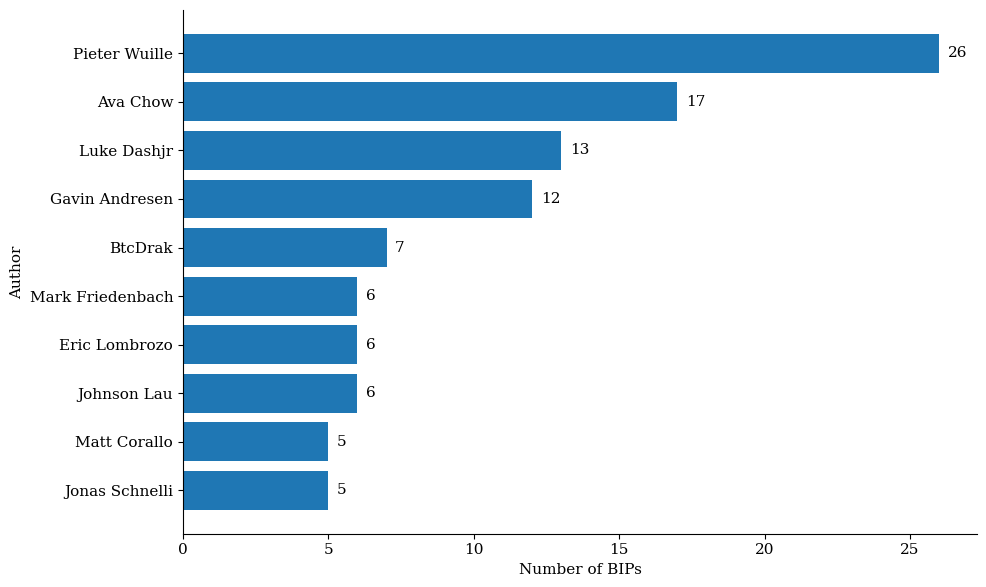

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to arrays
counts = np.array(counts)
authors = np.array(authors)

fig, ax = plt.subplots(figsize=(10, 6))

# Sort descending
sorted_idx = counts.argsort()[::-1]
authors_sorted = authors[sorted_idx]
counts_sorted = counts[sorted_idx]

bars = ax.barh(authors_sorted, counts_sorted)

ax.set_xlabel("Number of BIPs")
ax.set_ylabel("Author")

ax.invert_yaxis()

# Label bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3,
            bar.get_y() + bar.get_height()/2,
            f"{int(width)}",
            va='center')

# Remove clutter
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig("rq1_top_authors.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)


In [9]:
from collections import Counter
from datetime import datetime

In [10]:
# Extract and count BIPs per year from the nodes
years = []

for node in data['nodes']:
    created = node.get('created')
    if created:
        try:
            # Normalize date format to extract year
            year = datetime.strptime(created, "%Y-%m-%d").year
            years.append(year)
        except ValueError:
            continue  # skip malformed dates

In [11]:
year_counts = Counter(years)
sorted_years = sorted(year_counts.items())  # (year, count)

In [12]:
# Prepare data for plotting
x_years, y_counts = zip(*sorted_years)

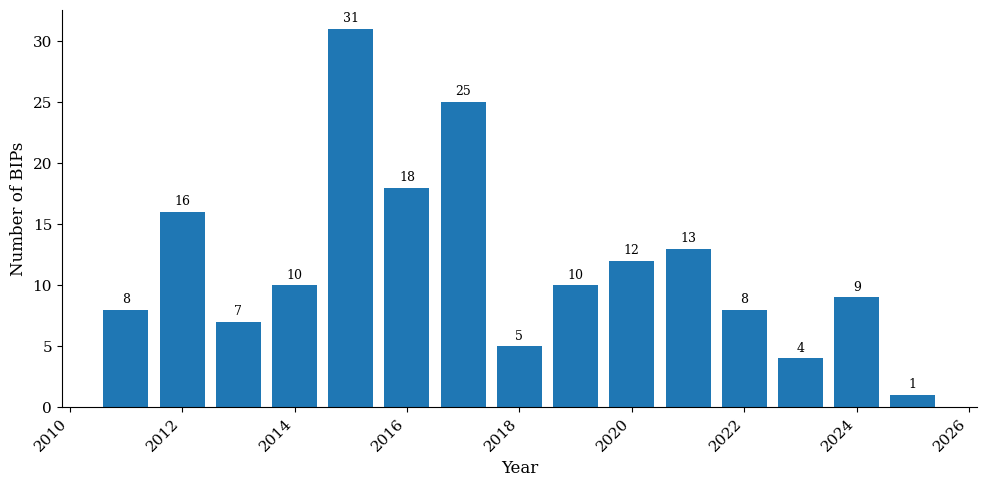

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Convert lists/tuples to arrays (safer for indexing and sorting if needed)
x_years = np.array(x_years)
y_counts = np.array(y_counts)

# Create figure + axis
fig, ax = plt.subplots(figsize=(10, 5))

# Bar plot (no color specified unless you want one)
bars = ax.bar(x_years, y_counts)

# Labels & title
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of BIPs", fontsize=12)

# Rotate x-ticks for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        str(int(height)),
        ha='center',
        va='bottom',
        fontsize=9
    )

# Clean up spines (academic style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()

# SAVE (PDF = ideal for LaTeX)
fig.savefig("figures/rq1_bips_over_time.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)


In [14]:
from collections import Counter
import matplotlib.pyplot as plt
# Step 1: Count BIPs per author
author_bip_counts = Counter()

for bip in data['nodes']:
    authors = bip.get('author')
    if isinstance(authors, list):
        for author in authors:
            name = author.split('<')[0].strip()
            author_bip_counts[name] += 1


In [15]:
# Step 2: Count how many authors have written N BIPs
contribution_distribution = Counter(author_bip_counts.values())

In [16]:
# Sort by number of BIPs
sorted_counts = sorted(contribution_distribution.items())
x_vals, y_vals = zip(*sorted_counts)

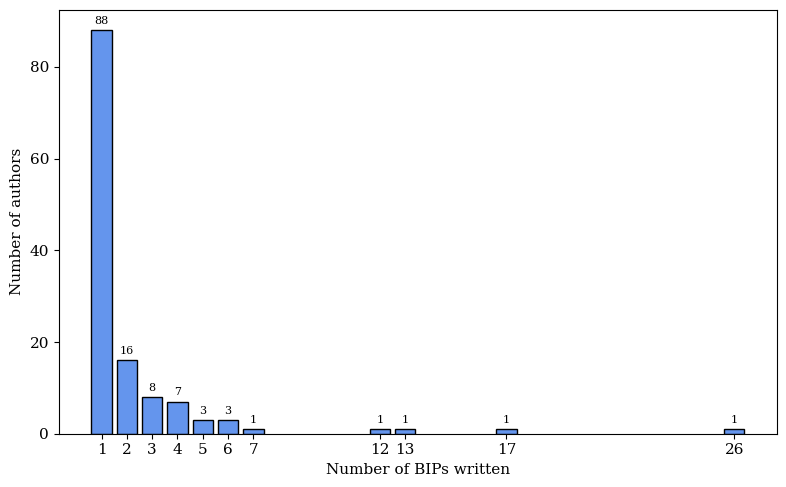

In [17]:
import matplotlib.pyplot as plt

# x_vals: number of BIPs written (e.g., [1, 2, 3, 4, ...])
# y_vals: number of authors with that many BIPs (same length)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(x_vals, y_vals, color="cornflowerblue", edgecolor="black")

ax.set_xlabel("Number of BIPs written")
ax.set_ylabel("Number of authors")

# Ensure nice, discrete x-ticks
ax.set_xticks(x_vals)

# Add count labels on top of bars (Matplotlib ≥ 3.4)
ax.bar_label(bars, padding=3, fontsize=8)

fig.tight_layout()

# For thesis figures it’s better to save than show
fig.savefig("figures/rq1_authors_histogram.pdf", dpi=300)
plt.show()
plt.close(fig)


In [18]:
from collections import Counter

# Step 1: Count BIPs per author
author_bip_counts = Counter()

for bip in data['nodes']:
    authors = bip.get('author')
    if isinstance(authors, list):
        for author in authors:
            name = author.split('<')[0].strip()
            author_bip_counts[name] += 1

# Step 2: Get total number of BIPs (based on distinct BIP IDs)
total_bips = len({bip['id'] for bip in data['nodes'] if 'id' in bip})

# Step 3: Get top 10 authors
top_10 = author_bip_counts.most_common(10)

# Step 4: Compute total BIPs by top 10 authors
bips_by_top_10 = sum(count for _, count in top_10)

# Step 5: Compute percentage
percentage = (bips_by_top_10 / total_bips) * 100

# Step 6: Print results
print("Top 10 BIP Authors (by number of BIPs):")
for author, count in top_10:
    print(f" - {author}: {count} BIPs")

print(f"\nTotal BIPs: {total_bips}")
print(f"BIPs by Top 10 Authors: {bips_by_top_10}")
print(f"Percentage of all BIPs: {percentage:.2f}%")


Top 10 BIP Authors (by number of BIPs):
 - Pieter Wuille: 26 BIPs
 - Ava Chow: 17 BIPs
 - Luke Dashjr: 13 BIPs
 - Gavin Andresen: 12 BIPs
 - BtcDrak: 7 BIPs
 - Johnson Lau: 6 BIPs
 - Eric Lombrozo: 6 BIPs
 - Mark Friedenbach: 6 BIPs
 - Jonas Schnelli: 5 BIPs
 - Matt Corallo: 5 BIPs

Total BIPs: 177
BIPs by Top 10 Authors: 103
Percentage of all BIPs: 58.19%


In [19]:
# Step 7: Count unique authors
unique_authors = set()

for bip in data['nodes']:
    authors = bip.get('author')
    if isinstance(authors, list):
        for author in authors:
            name = author.split('<')[0].strip()
            unique_authors.add(name)

num_unique_authors = len(unique_authors)

# Display
print(f"\nTotal Unique Authors: {num_unique_authors}")



Total Unique Authors: 130


In [20]:
import networkx as nx
from itertools import combinations
from collections import defaultdict
import matplotlib.pyplot as plt

def build_collaboration_network(data):
    G = nx.Graph()  # Undirected graph

    coauthor_counts = defaultdict(int)

    for bip in data['nodes']:
        authors = bip.get('author', [])
        if isinstance(authors, list) and len(authors) > 1:
            # Clean author names (strip email)
            clean_authors = [a.split('<')[0].strip() for a in authors]
            for a1, a2 in combinations(clean_authors, 2):
                # Sort to avoid (a,b) and (b,a) as separate pairs
                key = tuple(sorted([a1, a2]))
                coauthor_counts[key] += 1

    # Add nodes and edges
    for (a1, a2), weight in coauthor_counts.items():
        G.add_edge(a1, a2, weight=weight)

    return G


In [21]:
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.cm as cm
import numpy as np

def draw_collaboration_network(G):
    plt.figure(figsize=(12, 8))

    # Positioning
    pos = nx.spring_layout(
    G,
    k=3.5,          # MUCH more spread-out
    scale=4.0,      # expand layout outward
    iterations=300, # allow layout to stabilize
    seed=42
)
    weights = [G[u][v]['weight'] for u, v in G.edges]

    # --- Compute Degree (for size + font) ---
    degrees = dict(G.degree())
    node_sizes = [100 + degrees[n] * 40 for n in G.nodes()]  # MUCH smaller nodes

    # --- Compute Communities (clusters) ---
    communities = list(greedy_modularity_communities(G))
    cluster_map = {}
    for cid, community in enumerate(communities):
        for node in community:
            cluster_map[node] = cid

    # Generate unique colors for clusters
    colors = cm.Set3(np.linspace(0, 1, len(communities)))
    node_colors = [colors[cluster_map[n]] for n in G.nodes()]

    # --- Create edge colors matched to nodes ---
    edge_colors = []
    for u, v in G.edges():
        cid = cluster_map[u]      # or cluster_map[v]
        edge_colors.append(colors[cid])

    # --- Draw nodes ---
    nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9
)


    # --- Draw edges with matching cluster colors ---
    nx.draw_networkx_edges(
        G, pos,
        width=weights,
        edge_color=edge_colors,
        alpha=0.6
    )

    # --- Draw labels with degree-based font size ---
    for n, (x, y) in pos.items():
        fs = 4 + degrees[n] * 0.7
        plt.text(
            x, y + 0.03,
            n,
            fontsize=fs,
            ha='center',
            va='center'
        )

    plt.axis('off')
    plt.tight_layout()
    plt.savefig("figures/bip_collab_network.pdf", format="pdf", bbox_inches="tight")
    plt.show()


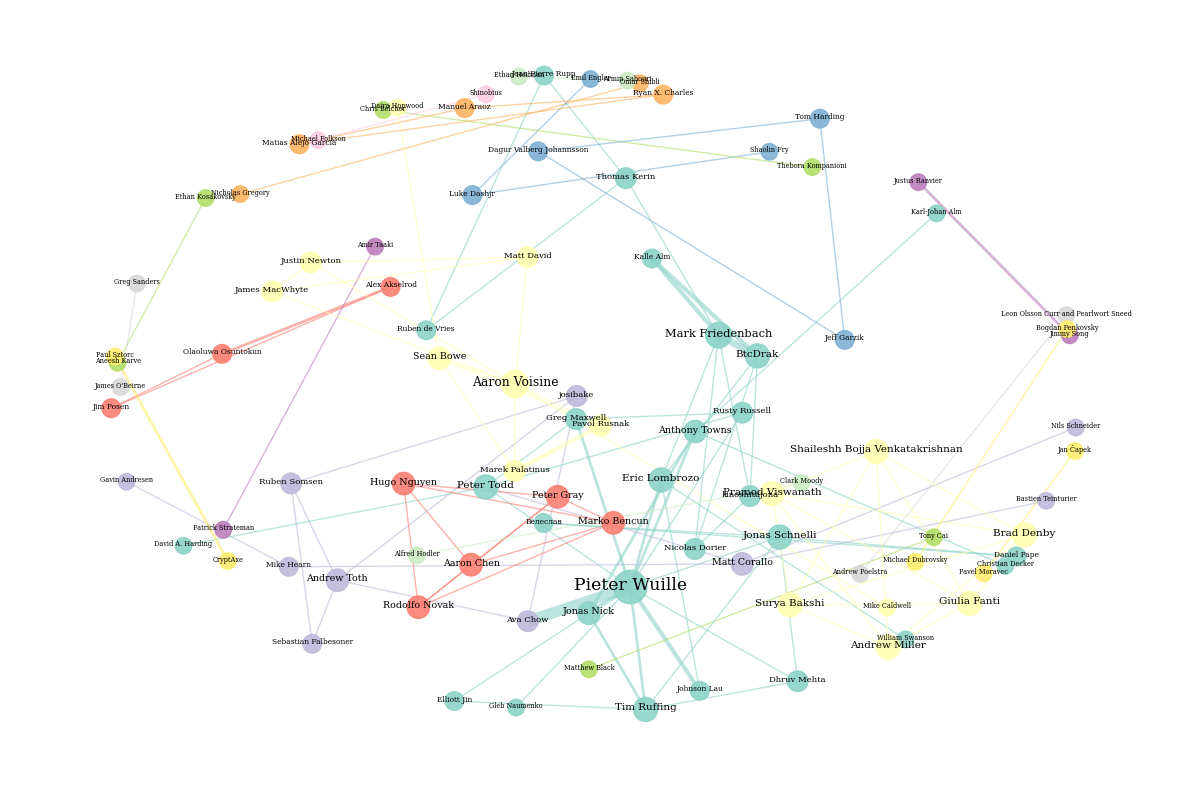

In [22]:
G_collab = build_collaboration_network(data)
draw_collaboration_network(G_collab)


In [23]:
largest_cc = max(nx.connected_components(G_collab), key=len)
G_main = G_collab.subgraph(largest_cc).copy()

In [24]:
def compute_centrality_scores(G):
    degree = nx.degree_centrality(G)
    betweenness = nx.betweenness_centrality(G)
    closeness = nx.closeness_centrality(G)
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

    centrality_data = []
    for node in G.nodes():
        centrality_data.append({
            'Author': node,
            'Degree': degree[node],
            'Betweenness': betweenness[node],
            'Closeness': closeness[node],
            'Eigenvector': eigenvector[node]
        })
    
    return sorted(centrality_data, key=lambda x: x['Eigenvector'], reverse=True)


In [25]:
centrality_results = compute_centrality_scores(G_main)

# Print top 5 most critical authors by eigenvector centrality
for entry in centrality_results[:10]:
    print(f"{entry['Author']} - Eigenvector: {entry['Eigenvector']:.3f}, Degree: {entry['Degree']:.2f}")


Pieter Wuille - Eigenvector: 0.563, Degree: 0.33
Tim Ruffing - Eigenvector: 0.316, Degree: 0.14
Jonas Schnelli - Eigenvector: 0.275, Degree: 0.14
Jonas Nick - Eigenvector: 0.258, Degree: 0.11
Dhruv Mehta - Eigenvector: 0.249, Degree: 0.08
Peter Todd - Eigenvector: 0.240, Degree: 0.14
Rusty Russell - Eigenvector: 0.220, Degree: 0.08
Greg Maxwell - Eigenvector: 0.220, Degree: 0.08
Eric Lombrozo - Eigenvector: 0.213, Degree: 0.14
Anthony Towns - Eigenvector: 0.195, Degree: 0.11


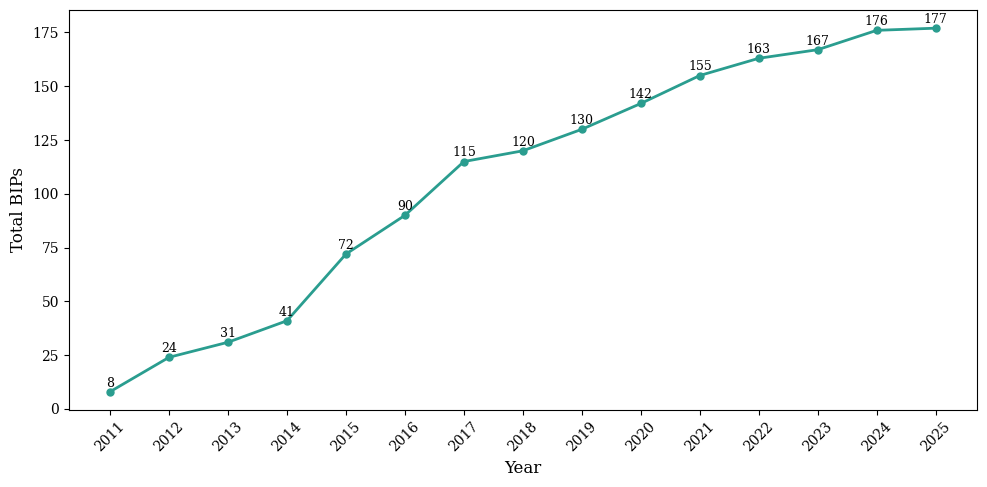

In [26]:
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt

# Step 1: Count BIPs per year
years = []

for node in data['nodes']:
    created = node.get('created')
    if created:
        try:
            year = datetime.strptime(created, "%Y-%m-%d").year
            years.append(year)
        except ValueError:
            continue

# Step 2: Sort years and compute cumulative total
year_counts = Counter(years)
all_years = sorted(year_counts.keys())

cumulative_counts = []
running_total = 0
for year in all_years:
    running_total += year_counts[year]
    cumulative_counts.append(running_total)

# Step 3: Plot cumulative line chart (clean thesis style)
plt.figure(figsize=(10, 5))

plt.plot(
    all_years,
    cumulative_counts,
    marker='o',
    markersize=5,
    linewidth=2,
    color="#2a9d8f"   # soft academic teal
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Total BIPs", fontsize=12)

# Remove gridlines (requested)
plt.grid(False)

# Add data labels for each point
for x, y in zip(all_years, cumulative_counts):
    plt.text(
        x, y + 1,                 # slight upward offset
        str(y),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(all_years, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

# Save as vector PDF for thesis
plt.savefig("figures/bip_cumulative_growth.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()
